In [1]:
import pandas as pd
import os
import json
import pandas as pd
import json
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np

from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder

In [2]:
# Here to verify we're using the GPU
print(torch.__version__)
print(torch.cuda.is_available())
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

2.5.1+cu121
True


In [3]:
df = pd.read_csv("Data/metadata_single_imputation_knn.csv")
print("Unique labels:", sorted(df["diagnosis"].unique()))
print("Num unique:", df["diagnosis"].nunique())
print("Any NaN in diagnosis?", df["diagnosis"].isna().sum())
print("dtype:", df["diagnosis"].dtype)

Unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Num unique: 10
Any NaN in diagnosis? 0
dtype: int64


#### Pre-Processing Dataset
Saving it as a copy as to not modify the original.

Modifications Made:
- Removed the feature 'anatom_site_special'. Was sparsely populate and did not add to many entries.

In [4]:
df = pd.read_csv('Data/metadata_original.csv')
df = df.drop(columns=['anatom_site_special']) # This feature is to sparsely populated.

# Following two columns are not useful for training purposes, so removing them early on before other processing begins.
df = df.drop(columns=['attribution'])
df = df.drop(columns=['copyright_license'])

df.to_csv('Data/metadata_processed.csv', index=False)

## Data Visualization
Mainly evaluating data here for either presentation purposes or for analytical purposes when figuring out what to do next. The contents here will change depending on what information I currently need.

In [5]:
# This section covers the gather of data metrics before they're graphed in the following code blocks.

# Adding this for redundency even though it should be defined earlier.
df = pd.read_csv('Data/metadata_processed.csv')

missing_counts = df.isnull().sum()
missing_cols = missing_counts[missing_counts > 0]
missing_percent = (missing_cols / len(df)) * 100

unique_missing_entries = df.isnull().any(axis=1).sum()
unique_missing_percent = (unique_missing_entries  / len(df)) * 100

print(f"Number of entries patients with missinge data: {unique_missing_entries}")
print(f"Percetnage of entries with missing data: {unique_missing_percent}\n")

print(f"Number of columns with missing entries: {len(missing_cols)}\n")
print(f"Column Missing Entries:\n{missing_cols}\n")
print(f"Missing Percentage: {missing_percent}")

Number of entries patients with missinge data: 1377
Percetnage of entries with missing data: 85.21039603960396

Number of columns with missing entries: 9

Column Missing Entries:
age_approx                  5
anatom_site_general       110
dermoscopic_type          346
diagnosis_3                51
diagnosis_confirm_type    578
family_hx_mm              857
fitzpatrick_skin_type     117
personal_hx_mm            731
sex                         5
dtype: int64

Missing Percentage: age_approx                 0.309406
anatom_site_general        6.806931
dermoscopic_type          21.410891
diagnosis_3                3.155941
diagnosis_confirm_type    35.767327
family_hx_mm              53.032178
fitzpatrick_skin_type      7.240099
personal_hx_mm            45.235149
sex                        0.309406
dtype: float64


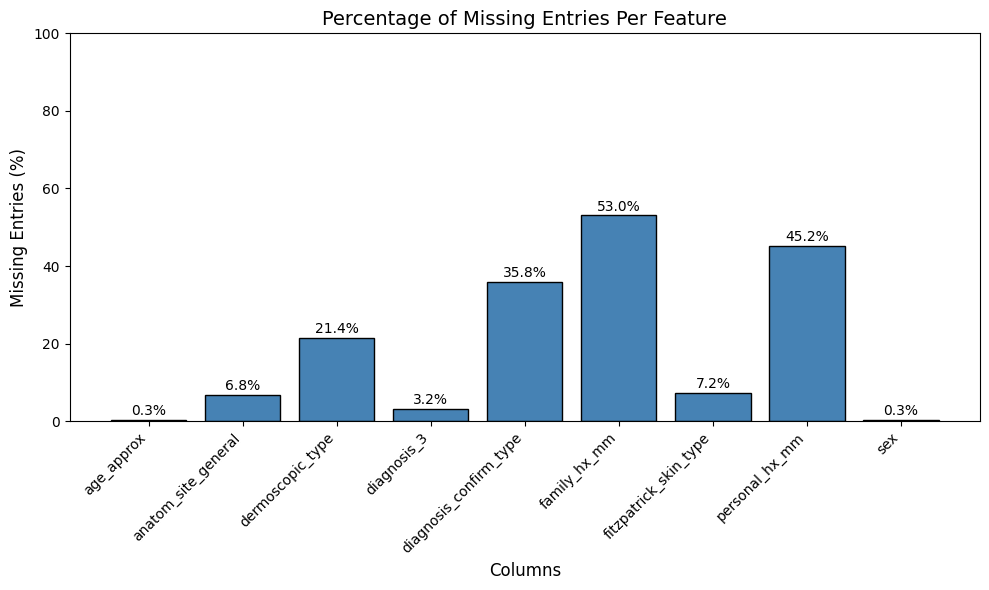

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(missing_percent.index, missing_percent.values, color='steelblue', edgecolor='black')

for bar, pct in zip(bars, missing_percent.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{pct:.1f}%',
        ha='center', va='bottom', fontsize=10
    )
 
ax.set_title('Percentage of Missing Entries Per Feature', fontsize=14)
ax.set_xlabel('Columns', fontsize=12)
ax.set_ylabel('Missing Entries (%)', fontsize=12)
ax.set_ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

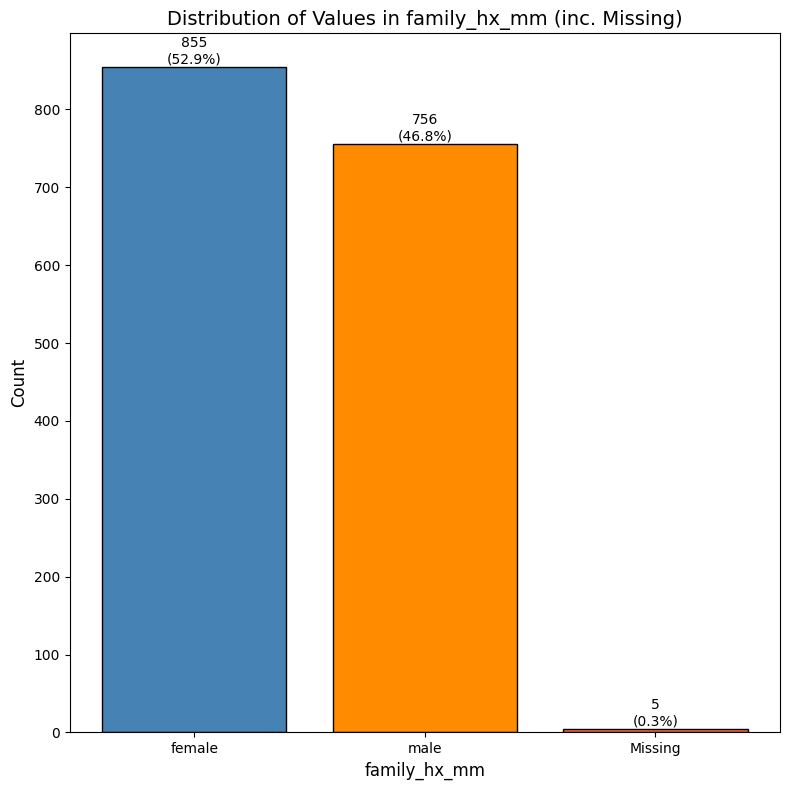

In [7]:
value_counts = df['sex'].value_counts(dropna=False)
value_counts.index = [str(x) if x is not None and str(x) != 'nan' else 'Missing' for x in value_counts.index]
 
fig, ax = plt.subplots(figsize=(8, 8))
 
bars = ax.bar(value_counts.index, value_counts.values, color=['steelblue', 'darkorange', 'tomato'], edgecolor='black')
 
# Add count and percentage labels on top of each bar
total = len(df)
for bar, count in zip(bars, value_counts.values):
    pct = (count / total) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{count}\n({pct:.1f}%)',
        ha='center', va='bottom', fontsize=10
    )
 
ax.set_title('Distribution of Values in family_hx_mm (inc. Missing)', fontsize=14)
ax.set_xlabel('family_hx_mm', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# Displaying all the unique values in each feature column (other than image ID) that will be used for training
# ! NOTE ! Image type may or may not be used for training purposes, evaluate that later to see if it would be relevant to my purposes.
df = pd.read_csv('Data/metadata_processed.csv')

features = ['anatom_site_general', 'benign_malignant', 'concomitant_biopsy', 
            'dermoscopic_type', 'family_hx_mm', 'fitzpatrick_skin_type',
            'image_type', 'personal_hx_mm', 'sex']

for feature in features:
    unique_vals = df[feature].unique()
    print(f"{feature} ({len(unique_vals)} unique)")
    print("------------------------------------")
    print(unique_vals)
    print()


anatom_site_general (9 unique)
------------------------------------
['anterior torso' 'upper extremity' nan 'posterior torso'
 'lower extremity' 'lateral torso' 'head/neck' 'oral/genital'
 'palms/soles']

benign_malignant (2 unique)
------------------------------------
['benign' 'malignant']

concomitant_biopsy (2 unique)
------------------------------------
[False  True]

dermoscopic_type (2 unique)
------------------------------------
['contact polarized' nan]

family_hx_mm (3 unique)
------------------------------------
[False True nan]

fitzpatrick_skin_type (5 unique)
------------------------------------
['II' 'I' 'III' nan 'IV']

image_type (3 unique)
------------------------------------
['dermoscopic' 'clinical: overview' 'clinical: close-up']

personal_hx_mm (3 unique)
------------------------------------
[False True nan]

sex (3 unique)
------------------------------------
['female' 'male' nan]



In [9]:
# Displaying all the unique values in each feature column (other than image ID) that will be used for training
# ! NOTE ! Image type may or may not be used for training purposes, evaluate that later to see if it would be relevant to my purposes.
df = pd.read_csv('Data/metadata_CCA.csv')

features = ['anatom_site_general', 'benign_malignant', 'concomitant_biopsy', 
            'dermoscopic_type', 'family_hx_mm', 'fitzpatrick_skin_type',
            'image_type', 'personal_hx_mm', 'sex']

for feature in features:
    unique_vals = df[feature].unique()
    print(f"{feature} ({len(unique_vals)} unique)")
    print("------------------------------------")
    print(unique_vals)
    print()


anatom_site_general (8 unique)
------------------------------------
['upper extremity' 'anterior torso' 'lateral torso' 'posterior torso'
 'lower extremity' 'oral/genital' 'head/neck' 'palms/soles']

benign_malignant (2 unique)
------------------------------------
['malignant' 'benign']

concomitant_biopsy (2 unique)
------------------------------------
[ True False]

dermoscopic_type (1 unique)
------------------------------------
['contact polarized']

family_hx_mm (2 unique)
------------------------------------
[False  True]

fitzpatrick_skin_type (4 unique)
------------------------------------
['II' 'I' 'III' 'IV']

image_type (1 unique)
------------------------------------
['dermoscopic']

personal_hx_mm (2 unique)
------------------------------------
[ True False]

sex (2 unique)
------------------------------------
['male' 'female']



## Data Processing
To reduce the overhead of training the model, I'll be listing out all the unique entries of each of the features and then encoding them to be numeric values for training purposes.

In [9]:
IMG_DIR = "Data/images/"
SAVE_DIR = "Models/"
metadata = { 
    "Original": "Data/metadata_original.csv",
    "Partial_Process": "Data/metadata_processed.csv",
    "CCA": "Data/metadata_CCA.csv",
    "CCA_Processed": "Data/metadata_CCA_encoded.csv",
    "Single_Imputation": "Data/metadata_single_imputation_encoded.csv"
}

In [7]:
# Only functions for CCA, other methods need slightly different handling for the NaN values.

# Exclude all diagnosis columns for training purposes, they're to specific to the diagnosis.
df = pd.read_csv(metadata.get("CCA"))

bool_cols = ['concomitant_biopsy', 'family_hx_mm', 'personal_hx_mm']
df[bool_cols] = df[bool_cols].astype(int)

df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['benign_malignant'] = df['benign_malignant'].map({'benign': 0, 'malignant': 1})

df['fitzpatrick_skin_type'] = df['fitzpatrick_skin_type'].map({'I': 1, 'II': 2, 'III': 3, 'IV': 4})

df = pd.get_dummies(df, columns=['anatom_site_general'], prefix='site', dtype=int)

diagnosis_map = {label: idx for idx, label in enumerate(df['diagnosis'].unique())}
df['diagnosis'] = df['diagnosis'].map(diagnosis_map)

# Saving the diagnosis mappings to ensure later understanding.
with open('Data/diagnosis_encoding.json', 'w') as f:
    json.dump(diagnosis_map, f, indent=2)

print("Diagnosis encoding:", diagnosis_map)


# When CCA is done, the features `dermoscopic_type` and `image_type` get reduced down to one class, making it so these features are just
# extra noise that add nothing. They will be removed.
df = df.drop(columns=['dermoscopic_type', 'image_type'])

# These directly relate to the predictor, so the diagnosis columns are being removed as well.
# 'diagnosis' will remain in the data for ease of accessing the predictor when evaluating output. Will not be used in training.
df = df.drop(columns=['diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_confirm_type', 'benign_malignant'])

df.to_csv('Data/metadata_single_imputation_encoded.csv', index=False)

Diagnosis encoding: {'basal cell carcinoma': 0, 'melanoma': 1, 'nevus': 2, 'seborrheic keratosis': 3, 'squamous cell carcinoma': 4, 'dermatofibroma': 5, 'actinic keratosis': 6, 'solar lentigo': 7}


In [8]:
df = pd.read_csv(metadata.get("Partial_Process"))

# Handle bool cols carefully — NaNs prevent direct astype(int)
bool_cols = ['concomitant_biopsy', 'family_hx_mm', 'personal_hx_mm']
df[bool_cols] = df[bool_cols].apply(pd.to_numeric, errors='coerce')  # NaNs stay as NaN

# These mappings pass NaNs through safely
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['benign_malignant'] = df['benign_malignant'].map({'benign': 0, 'malignant': 1})
df['fitzpatrick_skin_type'] = df['fitzpatrick_skin_type'].map({'I': 1, 'II': 2, 'III': 3, 'IV': 4})

# get_dummies handles NaNs fine — NaN rows get 0 across all site columns
# df = pd.get_dummies(df, columns=['anatom_site_general'], prefix='site', dtype=int)

anatom_site_general_map = {
    label: idx 
    for idx, label in enumerate(df['anatom_site_general'].dropna().unique())
}
df['anatom_site_general'] = df['anatom_site_general'].map(anatom_site_general_map)
# map() leaves NaN as NaN automatically when the key isn't in the dict

# Saving the diagnosis mappings to ensure later understanding.
with open('Data/anatom_site_general_encoding.json', 'w') as f:
    json.dump(anatom_site_general_map, f, indent=2)
print("Anatomical Site encoding:", anatom_site_general_map)


# Encode diagnosis and save mapping before dropping anything
diagnosis_map = {label: idx for idx, label in enumerate(df['diagnosis'].unique())}
df['diagnosis'] = df['diagnosis'].map(diagnosis_map)
with open('Data/diagnosis_encoding.json', 'w') as f:
    json.dump(diagnosis_map, f, indent=2)

# Drop columns not used in training
df = df.drop(columns=['dermoscopic_type', 'image_type'])
df = df.drop(columns=['diagnosis_1', 'diagnosis_2', 'diagnosis_3', 'diagnosis_confirm_type', 'benign_malignant'])

df.to_csv('Data/metadata_single_imputation_encoded.csv', index=False)

Anatomical Site encoding: {'anterior torso': 0, 'upper extremity': 1, 'posterior torso': 2, 'lower extremity': 3, 'lateral torso': 4, 'head/neck': 5, 'oral/genital': 6, 'palms/soles': 7}


## Model Definition
Defining the model here, so that it can be reused and trained in each of the sections. The main purpose of this project is to train multiple models on different datasets, so these functions and definitions are intended to be reused multiple times with different datasets.

The actual calls for the models will be called after their dataset is processed in their respective sections.

In [11]:
# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────
config = {
    # Model
    "pretrained_model":       "vgg19",
    "freeze_backbone":        True,
    "unfreeze_after_epoch":   5,
    # Architecture
    "image_embed_dim":        512,      # VGG-19 classifier head outputs 4096, but we'll project to 512
    "metadata_embed_dim":     128,
    "fusion_hidden_dim":      256,
    "dropout_rate":           0.4,
    "num_classes":            10,
    "num_metadata_features":  14,
    # Training
    "batch_size":             16,       # VGG-19 is much heavier than EfficientNet-B3, reduce if OOM
    "num_epochs":             20,
    "learning_rate":          1e-4,
    "weight_decay":           1e-5,
    "lr_scheduler":           "cosine",
    # Data
    "image_size":             224,      # VGG-19 native resolution
}

# Metadata columns in the exact order they appear after encoding
# (order must be consistent between dataset prep and model input)
METADATA_COLS = [
    'age_approx',
    'concomitant_biopsy',
    'family_hx_mm',
    'fitzpatrick_skin_type',
    'personal_hx_mm',
    'sex',
    'site_anterior torso',
    'site_head/neck',
    'site_lateral torso',
    'site_lower extremity',
    'site_oral/genital',
    'site_palms/soles',
    'site_posterior torso',
    'site_upper extremity',
]

In [12]:
# ─────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────
class SkinCancerDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image
        img_path = f"{self.image_dir}/{row['isic_id']}.jpg"
        image    = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Metadata
        metadata = torch.tensor(
            row[METADATA_COLS].values.astype(float),
            dtype=torch.float32
        )

        # Label
        label = torch.tensor(row['diagnosis'], dtype=torch.long)

        return image, metadata, label

In [13]:
# ─────────────────────────────────────────────
# TRANSFORMS
# ─────────────────────────────────────────────
def get_transforms(image_size, mode="train"):
    if mode == "train":
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(20),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406],
                                 [0.229, 0.224, 0.225]),
        ])

# ─────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────
class MultimodalSkinClassifier(nn.Module):
    def __init__(self, config):
        super().__init__()

        # ── Image branch (EfficientNet-B3 backbone) ──
        backbone = models.efficientnet_b3(weights="IMAGENET1K_V1")
        in_features = backbone.classifier[1].in_features  # 1536 for B3
        backbone.classifier = nn.Identity()
        self.image_branch = backbone

        self.image_head = nn.Sequential(
            nn.Linear(in_features, config["image_embed_dim"]),
            nn.BatchNorm1d(config["image_embed_dim"]),
            nn.ReLU(),
            nn.Dropout(config["dropout_rate"]),
        )

        # ── Metadata branch ──
        self.metadata_branch = nn.Sequential(
            nn.Linear(config["num_metadata_features"], 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(config["dropout_rate"]),
            nn.Linear(64, config["metadata_embed_dim"]),
            nn.ReLU(),
        )

        # ── Fusion + classifier ──
        fusion_in = config["image_embed_dim"] + config["metadata_embed_dim"]
        self.classifier = nn.Sequential(
            nn.Linear(fusion_in, config["fusion_hidden_dim"]),
            nn.BatchNorm1d(config["fusion_hidden_dim"]),
            nn.ReLU(),
            nn.Dropout(config["dropout_rate"]),
            nn.Linear(config["fusion_hidden_dim"], config["num_classes"]),
        )

    def forward(self, image, metadata):
        img_feat  = self.image_branch(image)
        img_feat  = self.image_head(img_feat)
        meta_feat = self.metadata_branch(metadata)
        fused     = torch.cat([img_feat, meta_feat], dim=1)
        return self.classifier(fused)

    def freeze_backbone(self):
        for param in self.image_branch.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.image_branch.parameters():
            param.requires_grad = True

In [14]:
# Call this before training each model.
def train_and_val_loader(df):
    # df would be a csv read using pd.read_csv(...)
    df = df.copy()  # avoid mutating the original
    df['diagnosis'] = df['diagnosis'].astype(int)

    train_df, val_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df['diagnosis']   # ensures class balance across both splits
    )

    print(f"Train samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")

    train_dataset = SkinCancerDataset(train_df, IMG_DIR, get_transforms(config["image_size"], "train"))
    val_dataset   = SkinCancerDataset(val_df,   IMG_DIR, get_transforms(config["image_size"], "val"))

    train_loader = DataLoader(
        train_dataset,
        batch_size=config["batch_size"],
        shuffle=True,
        num_workers=0,        # parallel data loading — tune based on your CPU cores
        pin_memory=True,      # speeds up CPU → GPU transfer
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=config["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True,
    )

    return val_loader, train_loader

In [15]:
def train(config, model, train_loader, val_loader, save_dir):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on: {device}")
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"]
    )

    if config["lr_scheduler"] == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=config["num_epochs"]
        )
    elif config["lr_scheduler"] == "plateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, patience=3, factor=0.5
        )

    criterion = nn.CrossEntropyLoss()

    if config["freeze_backbone"]:
        model.freeze_backbone()
        print("Backbone frozen — training head only")

    best_val_acc = 0
    history = []

    for epoch in range(config["num_epochs"]):

        # Unfreeze backbone after N epochs for fine-tuning
        if config["freeze_backbone"] and epoch == config["unfreeze_after_epoch"]:
            model.unfreeze_backbone()
            print(f"\n[Epoch {epoch+1}] Backbone unfrozen — fine-tuning entire network")

        # ── Train ──
        model.train()
        train_loss, correct, total = 0, 0, 0

        for images, metadata, labels in train_loader:
            images   = images.to(device)
            metadata = metadata.to(device)
            labels   = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images, metadata)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

        # ── Validate ──
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0

        with torch.no_grad():
            for images, metadata, labels in val_loader:
                images   = images.to(device)
                metadata = metadata.to(device)
                labels   = labels.to(device)

                outputs   = model(images, metadata)
                val_loss += criterion(outputs, labels).item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        train_acc = correct / total
        val_acc   = val_correct / val_total
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss / len(val_loader)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f"{save_dir}/best_model.pth")
            print(f"  ↳ New best model saved (val acc: {val_acc:.4f})")

        # Scheduler step
        if config["lr_scheduler"] == "plateau":
            scheduler.step(avg_val_loss)
        else:
            scheduler.step()

        # Log epoch
        epoch_log = {
            "epoch":      epoch + 1,
            "train_loss": avg_train_loss,
            "train_acc":  train_acc,
            "val_loss":   avg_val_loss,
            "val_acc":    val_acc,
        }
        history.append(epoch_log)
        print(f"Epoch {epoch+1:>3}/{config['num_epochs']} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Save full training history
    with open(f"{save_dir}/history.json", "w") as f:
        json.dump(history, f, indent=2)
    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    print(f"History saved to {save_dir}/history.json")

    return {"best_val_acc": best_val_acc, "history": history}

# ─────────────────────────────────────────────
# RUN
# ─────────────────────────────────────────────
model   = MultimodalSkinClassifier(config)
val_loader, train_loader = train_and_val_loader(df= pd.read_csv("Data/metadata_single_imputation_knn.csv"))

results = train(config, model, train_loader, val_loader, save_dir=SAVE_DIR)

Train samples: 1292
Val samples:   324
Training on: cuda
Backbone frozen — training head only
  ↳ New best model saved (val acc: 0.5648)
Epoch   1/20 | Train Loss: 1.9181 | Train Acc: 0.3591 | Val Loss: 1.6064 | Val Acc: 0.5648
  ↳ New best model saved (val acc: 0.5802)
Epoch   2/20 | Train Loss: 1.5274 | Train Acc: 0.5108 | Val Loss: 1.4156 | Val Acc: 0.5802
Epoch   3/20 | Train Loss: 1.3760 | Train Acc: 0.5472 | Val Loss: 1.3496 | Val Acc: 0.5772
  ↳ New best model saved (val acc: 0.6080)
Epoch   4/20 | Train Loss: 1.3195 | Train Acc: 0.5604 | Val Loss: 1.2654 | Val Acc: 0.6080
Epoch   5/20 | Train Loss: 1.2785 | Train Acc: 0.5666 | Val Loss: 1.2644 | Val Acc: 0.6049

[Epoch 6] Backbone unfrozen — fine-tuning entire network
  ↳ New best model saved (val acc: 0.6265)
Epoch   6/20 | Train Loss: 1.2306 | Train Acc: 0.5875 | Val Loss: 1.1842 | Val Acc: 0.6265
  ↳ New best model saved (val acc: 0.6358)
Epoch   7/20 | Train Loss: 1.1471 | Train Acc: 0.6029 | Val Loss: 1.1582 | Val Acc: 0.6

## Complete Case Analysis
This is a naive approach, considering it would elimate 83% of the dataset. However, it would be interesting to see the results of this naive approach, as it won't take much effort to demostrate just why this commonly used and default approach is a poor fit for this dataset.

In [ ]:
# Preparing CCA Dataset
# Base dataset being used
df_cca = pd.read_csv('Data/metadata_processed.csv')

# Remove rows with missing entries in the dataset
df_cca = df_cca.dropna()

# Save the modified dataset in a new csv file called metadata_CCA
df_cca.to_csv('Data/metadata_CCA.csv', index=False)

# Do an analysis of how many unique patients are included in the new CCA dataset
unique_patients = df_cca['patient_id'].nunique()
print(f"Total rows after removing missing entries: {len(df_cca)}")
print(f"Number of unique patients in CCA dataset: {unique_patients}")


Total rows after removing missing entries: 239
Number of unique patients in CCA dataset: 156


## Single Imputation
For this, I decided to use KNN imputation. This will let the inputed variables reflect what others in the similar population share.

In [16]:
df = pd.read_csv(metadata.get("Single_Imputation"))

categorical_cols = ['sex', 'anatom_site_general', 'family_hx_mm', 'personal_hx_mm', 'fitzpatrick_skin_type']
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    mask = df[col].notna()
    df.loc[mask, col] = le.fit_transform(df.loc[mask, col])
    encoders[col] = le

# Shift fitzpatrick to start from 1 instead of 0
df['fitzpatrick_skin_type'] = df['fitzpatrick_skin_type'] + 1

# Columns to exclude from imputation (IDs or non-numeric)
drop_cols = ['isic_id', 'lesion_id', 'patient_id', 'diagnosis']
df_to_impute = df.drop(columns=drop_cols, errors='ignore')

imputer = KNNImputer(n_neighbors=5, weights='distance')
df_imputed_array = imputer.fit_transform(df_to_impute)
df_imputed = pd.DataFrame(df_imputed_array, columns=df_to_impute.columns)
df_imputed[categorical_cols] = df_imputed[categorical_cols].round().astype(int) # Without this we have things like family history being .2

# Reattaching the dropped columns, they're still needed.
for col in drop_cols:
    if col in df.columns:
        df_imputed[col] = df[col].values

df_imputed.to_csv('Data/metadata_single_imputation_knn.csv', index=False)

In [17]:
print(df_imputed['anatom_site_general'].isna().sum())
print(df_imputed['anatom_site_general'].unique())

0
[0 1 2 3 4 5 6 7]


In [18]:
# One-Hot-Encoding the anatomical site feature so that it's represented with numeric features

with open('Data/anatom_site_general_encoding.json', 'r') as f:
    anatom_site_general_map = json.load(f)

inverse_map = {v: k for k, v in anatom_site_general_map.items()}

df_imputed['anatom_site_general'] = df_imputed['anatom_site_general'].map(
    lambda x: inverse_map.get(int(x))
)

df_imputed = pd.get_dummies(df_imputed, columns=['anatom_site_general'], prefix='site', dtype=int)

df_imputed.to_csv('Data/metadata_single_imputation_knn.csv', index=False)

In [19]:
df_imputed = pd.DataFrame(df_imputed_array, columns=df_to_impute.columns)

# Check for NaNs
print("NaNs per column:")
print(df_imputed.isna().sum())

# Check for Infs
print("\nInfs per column:")
print((df_imputed == float('inf')).sum())

# Check dtypes
print("\nDtypes:")
print(df_imputed.dtypes)

NaNs per column:
age_approx               0
anatom_site_general      0
concomitant_biopsy       0
family_hx_mm             0
fitzpatrick_skin_type    0
personal_hx_mm           0
sex                      0
dtype: int64

Infs per column:
age_approx               0
anatom_site_general      0
concomitant_biopsy       0
family_hx_mm             0
fitzpatrick_skin_type    0
personal_hx_mm           0
sex                      0
dtype: int64

Dtypes:
age_approx               float64
anatom_site_general      float64
concomitant_biopsy       float64
family_hx_mm             float64
fitzpatrick_skin_type    float64
personal_hx_mm           float64
sex                      float64
dtype: object
